In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('placement.csv')

df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


C:\Users\ACER\AppData\Local\Temp\ipykernel_12256\1975382824.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])
C:\Users\ACER\AppData\Local\Temp\ipykernel_12256\1975382824.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


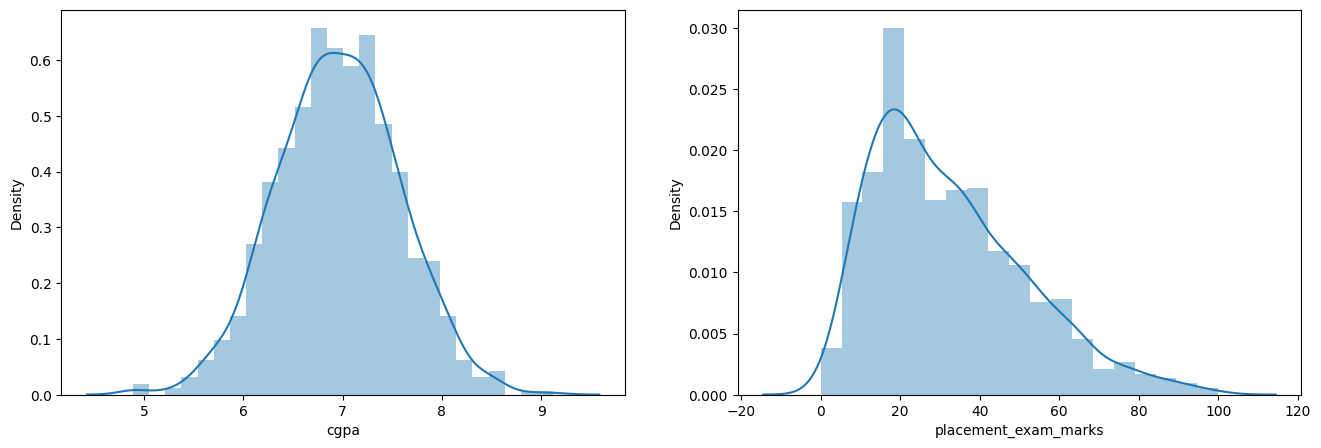

In [24]:
plt.figure(figsize=(16,5))

plt.subplot(1,2,1)
sns.distplot(df['cgpa'])

plt.subplot(1,2,2)
sns.distplot(df['placement_exam_marks'])

plt.show()

In [25]:
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

In [26]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

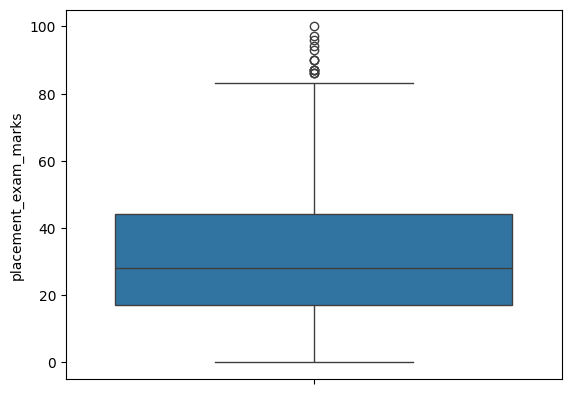

In [27]:
sns.boxplot(df['placement_exam_marks'])

In [28]:
Q1 = df['placement_exam_marks'].quantile(0.25)  #25th Percentile
Q3 = df['placement_exam_marks'].quantile(0.75)  #75th Percentile

IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR

In [29]:
Q1,Q3,IQR

(np.float64(17.0), np.float64(44.0), np.float64(27.0))

In [30]:
print("upper_limit : ",upper_limit)
print("lower_limit : ",lower_limit)

upper_limit :  84.5
lower_limit :  -23.5


In [31]:
df[df['placement_exam_marks'] > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [32]:
df[df['placement_exam_marks'] < lower_limit]

,cgpa,placement_exam_marks,placed


### Trimming


In [33]:
new_df = df[df['placement_exam_marks'] < upper_limit]

In [34]:
new_df.shape

(985, 3)

C:\Users\ACER\AppData\Local\Temp\ipykernel_12256\1997500346.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])
C:\Users\ACER\AppData\Local\Temp\ipykernel_12256\1997500346.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['placement_exam_marks'])


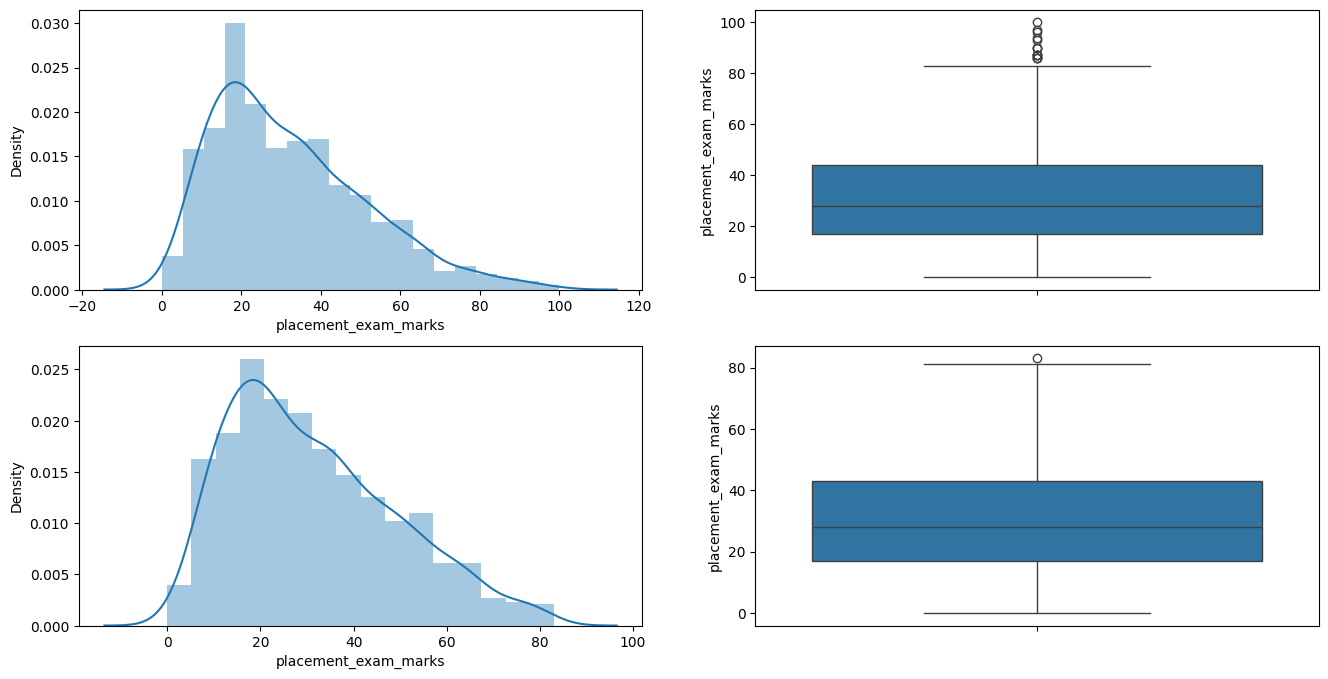

In [35]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['placement_exam_marks'])

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.distplot(new_df['placement_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(new_df['placement_exam_marks'])
plt.show()

In [36]:
new_df_cap = df.copy()
new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upper_limit, #if placement_exam_marks > upper limit
    upper_limit, # replace wiht upper limit
    np.where(
        new_df_cap['placement_exam_marks'] < lower_limit, #else if placement_exam_marks < lower limit
        lower_limit, #replace with lower limit
        new_df_cap['placement_exam_marks'] #else leave the same 
    )
)

In [37]:
new_df_cap.shape

(1000, 3)

C:\Users\ACER\AppData\Local\Temp\ipykernel_12256\3712238192.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])
C:\Users\ACER\AppData\Local\Temp\ipykernel_12256\3712238192.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df_cap['placement_exam_marks'])


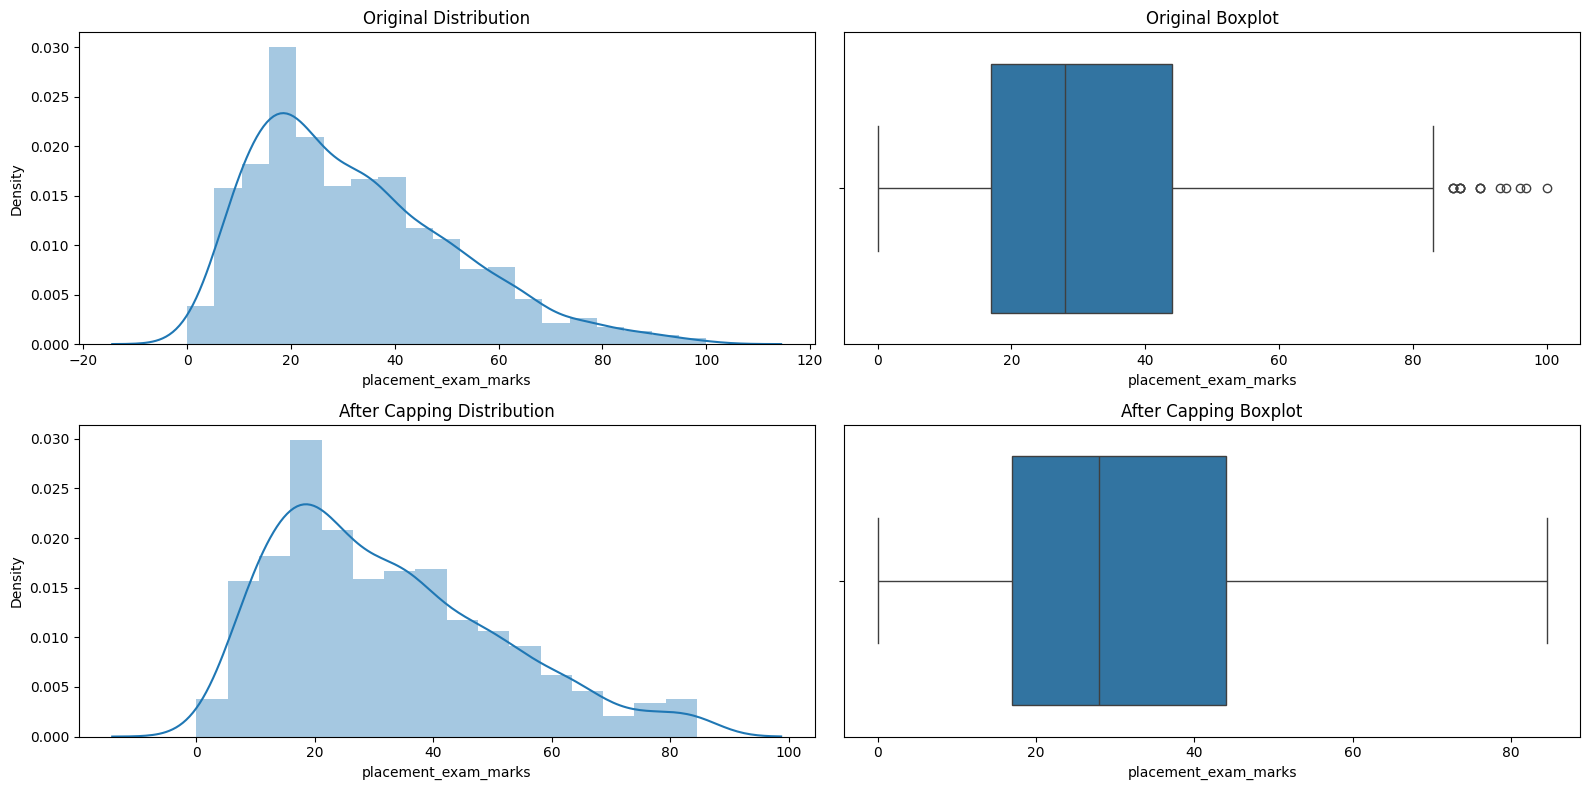

In [38]:
plt.figure(figsize=(16,8))

plt.subplot(2,2,1)
sns.distplot(df['placement_exam_marks'])
plt.title('Original Distribution')

plt.subplot(2,2,2)
sns.boxplot(x=df['placement_exam_marks'])
plt.title('Original Boxplot')

plt.subplot(2,2,3)
sns.distplot(new_df_cap['placement_exam_marks'])
plt.title('After Capping Distribution')

plt.subplot(2,2,4)
sns.boxplot(x=new_df_cap['placement_exam_marks'])
plt.title('After Capping Boxplot')

plt.tight_layout()
plt.show()